# 🍽️ Zomato Restaurant Data — Exploratory Data Analysis
**Goal:** Understand what makes a restaurant popular on Zomato — 
ratings, cuisines, cost, location, and delivery options.

**Dataset:** Zomato Restaurants (Kaggle) | ~9,500 restaurants  
**Tools:** Python, Pandas, Seaborn, Matplotlib

In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [155]:
data = pd.read_csv("C:/Users/Dell/zomato_eda/data/zomato.csv", encoding='latin-1')


In [156]:
print(f"Shape: ", data.shape)
print(f"\n Columns: ",data.columns.tolist())

Shape:  (9551, 21)

 Columns:  ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [157]:
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 1. Data Overview


In [158]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [159]:
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 2. Missing values and Duplicates



In [160]:
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [161]:
missing = data.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print(missing)

Cuisines    9
dtype: int64


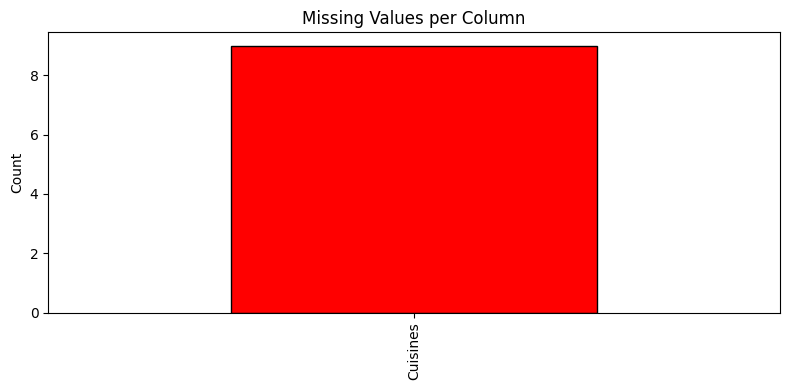

In [162]:
plt.figure(figsize=(8,4))
missing.plot(kind="bar", color="red", edgecolor="black")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Only the `cuisines` column contains missing values, and the count is minimal  
Since the proportion is very small relative to the dataset size, these rows can be safely removed without impacting analysis  

In [163]:
data.dropna(inplace=True)
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [164]:
print(f"Duplicated rows: ", data.duplicated().sum())

Duplicated rows:  0


### Adding country names to Country codes

In [ ]:
#These are not official international standards like ISO 3166
# They are specific to the Zomato dataset and may not correspond to any widely recognized coding system.

country_map = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Philippines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "UAE",
    215: "UK",
    216: "USA"
}

data['Country'] = data['Country Code'].map(country_map)
print(f"Unique Countries:\n {data['Country'].unique()}")

Unique Countries:
 <StringArray>
[ 'Philippines',       'Brazil',          'USA',    'Australia',
       'Canada',    'Singapore',          'UAE',        'India',
    'Indonesia',  'New Zealand',           'UK',        'Qatar',
 'South Africa',    'Sri Lanka',       'Turkey']
Length: 15, dtype: str


## 3. Summary Stats

In [166]:
print("Numerical Summary: \n",data.describe())

Numerical Summary: 
        Restaurant ID  Country Code    Longitude     Latitude  \
count   9.542000e+03   9542.000000  9542.000000  9542.000000   
mean    9.043301e+06     18.179208    64.274997    25.848532   
std     8.791967e+06     56.451600    41.197602    11.010094   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019312e+05      1.000000    77.081565    28.478658   
50%     6.002726e+06      1.000000    77.192031    28.570444   
75%     1.835260e+07      1.000000    77.282043    28.642711   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9542.000000  9542.000000       9542.000000   9542.000000  
mean            1200.326137     1.804968          2.665238    156.772060  
std            16128.743876     0.905563          1.516588    430.203324  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000

In [167]:
print(f"Categorical Summary: \n", data.describe(include="object"))

Categorical Summary: 
         Restaurant Name       City                     Address  \
count              9542       9542                        9542   
unique             7437        140                        8910   
top     Cafe Coffee Day  New Delhi  Dilli Haat, INA, New Delhi   
freq                 83       5473                          11   

               Locality            Locality Verbose      Cuisines  \
count              9542                        9542          9542   
unique             1206                        1263          1825   
top     Connaught Place  Connaught Place, New Delhi  North Indian   
freq                122                         122           936   

                  Currency Has Table booking Has Online delivery  \
count                 9542              9542                9542   
unique                  12                 2                   2   
top     Indian Rupees(Rs.)                No                  No   
freq                  8652  

C:\Users\Dell\AppData\Local\Temp\ipykernel_28312\1673985097.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Categorical Summary: \n", data.describe(include="object"))


## 4. Top Restaurants

In [168]:
top_restuarants= data["Restaurant Name"].value_counts().head(10)
print(f"Top Restaurants: \n", top_restuarants)

Top Restaurants: 
 Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


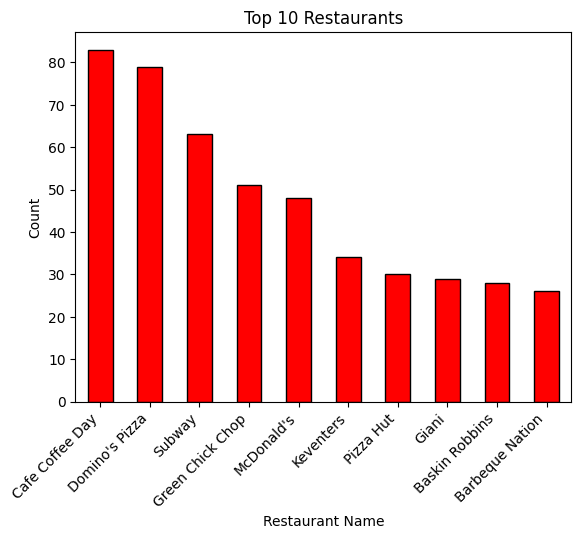

In [169]:
top_restuarants.plot(kind="bar", color="red", edgecolor="black")
plt.title("Top 10 Restaurants")
plt.xlabel("Restaurant Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right") #horizontal alignment needed
plt.show()

Aggregate rating
0.0 → not rated (should range: 0 to ~5)

In [170]:
data = data[data["Aggregate rating"]>0]
data["Aggregate rating"]
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,7.394000e+03,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000,7394.000000
mean,7.146271e+06,23.034082,63.653592,26.175821,1450.157831,1.970517,3.439505,202.062483
std,8.442275e+06,63.107149,44.380399,11.270628,18314.593716,0.930536,0.552129,479.305610
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,1.800000,4.000000
25%,1.529625e+04,1.000000,77.083029,28.475488,300.000000,1.000000,3.000000,19.000000
50%,3.120070e+05,1.000000,77.191952,28.569953,500.000000,2.000000,3.400000,60.000000
75%,1.821955e+07,1.000000,77.272507,28.645140,800.000000,3.000000,3.800000,181.000000
max,1.849606e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 5. Top Cities

In [171]:
top_cities = data["City"].value_counts().head(5)
print(f"Top Cities: \n", top_cities)

Top Cities: 
 City
New Delhi    4048
Gurgaon       890
Noida         696
Faridabad     151
Ghaziabad      23
Name: count, dtype: int64


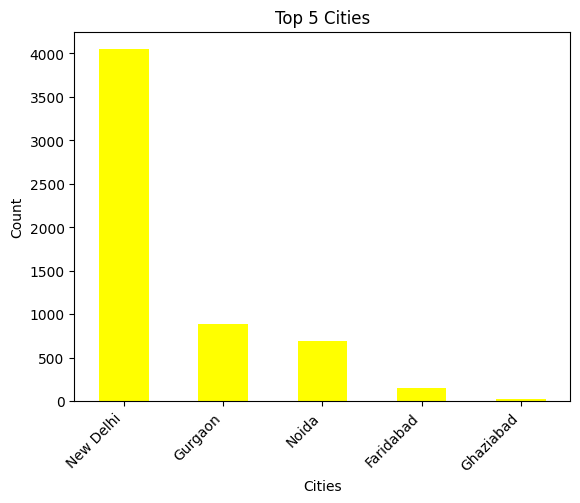

In [172]:
top_cities.plot(kind="bar", color="yellow")
plt.title("Top 5 Cities")
plt.xlabel("Cities")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

## 6. Rating Distribution

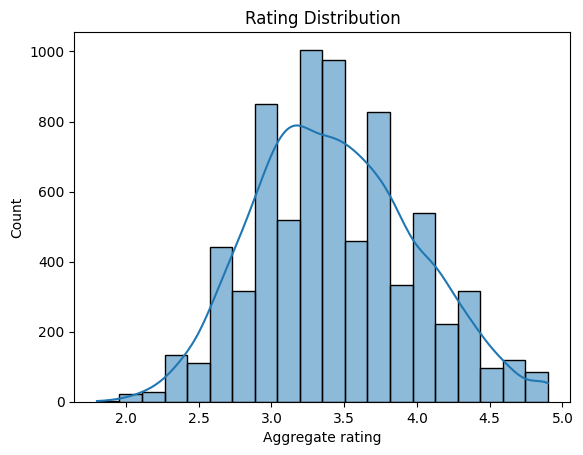

In [173]:
sns.histplot(data["Aggregate rating"], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

In [174]:
data["Aggregate rating"].describe()

count    7394.000000
mean        3.439505
std         0.552129
min         1.800000
25%         3.000000
50%         3.400000
75%         3.800000
max         4.900000
Name: Aggregate rating, dtype: float64

## 7. Votes Distribution

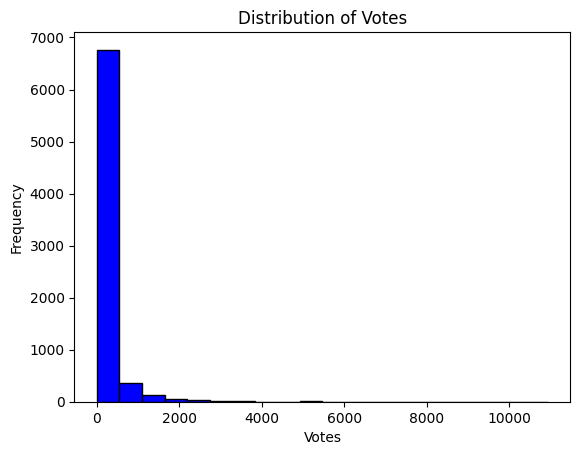

In [175]:
plt.hist(data["Votes"], bins=20, color="blue", edgecolor="black")
plt.title("Distribution of Votes")
plt.xlabel("Votes")
plt.ylabel("Frequency")
plt.show()

Data is highly skewed  
Most restaurants/items have very low votes  
A few have very high votes (long tail on the right)

## 7. Price Range
how expensive a restaurant is from 1 to 4 

In [176]:
price= data["Price range"].value_counts()
print(f"Price Range: \n", price)


Price Range: 
 Price range
1    2738
2    2711
3    1370
4     575
Name: count, dtype: int64


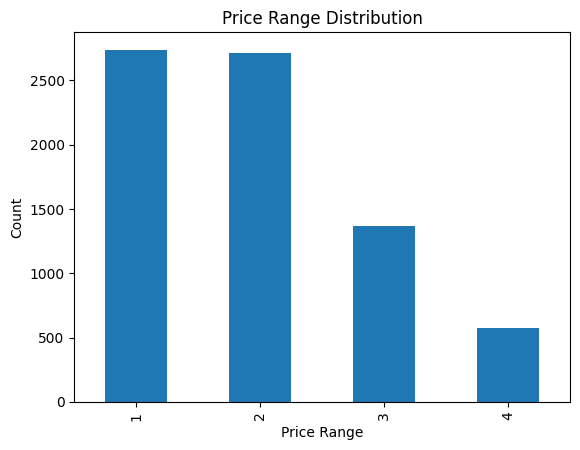

In [177]:
price.plot(kind="bar")
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

## 8. online Delivery impact

In [178]:
delivery = data.groupby('Has Online delivery')["Aggregate rating"].mean()
print(f"Delivery vs Rating: \n" , delivery)


Delivery vs Rating: 
 Has Online delivery
No     3.466720
Yes    3.381274
Name: Aggregate rating, dtype: float64


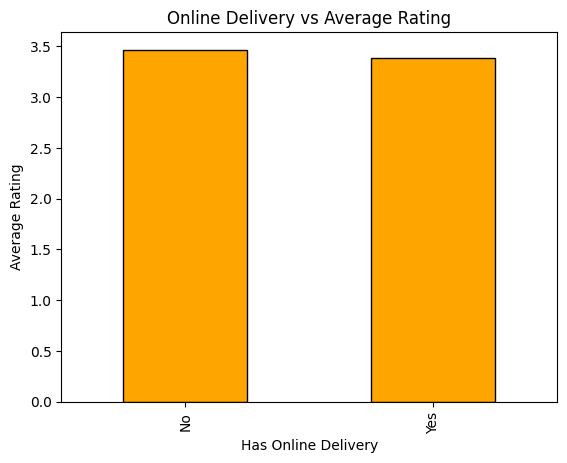

In [179]:
delivery.plot(kind="bar", color='orange', edgecolor='black')
plt.title("Online Delivery vs Average Rating")
plt.xlabel("Has Online Delivery")   
plt.ylabel("Average Rating")
plt.show()

Having online delivery does NOT significantly impact ratings  
Online delivery → higher ratings

## 9. Table booking vs Rating

In [194]:
booking= data.groupby("Has Table booking")["Aggregate rating"].mean()
print(f"Table Booking vs Rating: \n", booking)

Table Booking vs Rating: 
 Has Table booking
No     3.413322
Yes    3.587579
Name: Aggregate rating, dtype: float64


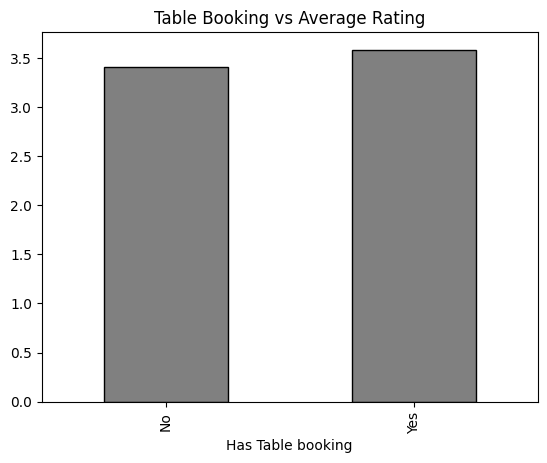

In [195]:
booking.plot(kind="bar", color="Grey", edgecolor="black")
plt.title("Table Booking vs Average Rating")
plt.show()

Table booking → even higher ratings

## . Country-Level Analysis

In [180]:
country_count = data["Country Code"].value_counts()
print(f"Country Code Counts: \n{country_count}")

Country Code Counts: 
Country Code
1      6513
216     422
215      79
214      60
189      60
30       55
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


In [186]:
country_count= data["Country"].value_counts()
print(f"Country Counts: \n{country_count}")

Country Counts: 
Country
India           6513
USA              422
UK                79
UAE               60
South Africa      60
Brazil            55
New Zealand       40
Turkey            34
Australia         24
Philippines       22
Indonesia         21
Singapore         20
Qatar             20
Sri Lanka         20
Canada             4
Name: count, dtype: int64


### Average rating per country

In [188]:
country_rating = data.groupby("Country Code")["Aggregate rating"].mean().sort_values(ascending=False)
print(f"Average Rating by Country: \n{country_rating}.sort_values(ascending=False)")

Average Rating by Country: 
Country Code
162    4.468182
208    4.300000
94     4.295238
148    4.262500
214    4.233333
189    4.210000
215    4.139241
30     4.105455
166    4.060000
216    4.035782
191    3.870000
14     3.658333
37     3.575000
184    3.575000
1      3.352034
Name: Aggregate rating, dtype: float64.sort_values(ascending=False)


India's Dominance: Nearly 90% of the records in this dataset are from India.  
Highly Rated Outliers: While the Philippines has one of the lowest  restaurant counts (22), it holds the highest average rating (~4.47).

## x. Correlation


In [182]:
data.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='str')

In [183]:
corr = data[["Aggregate rating", "Votes","Average Cost for two", "Price range"]].corr()
print(f"Correlation: \n", corr)

Correlation: 
                       Aggregate rating     Votes  Average Cost for two  \
Aggregate rating              1.000000  0.408667              0.076919   
Votes                         0.408667  1.000000              0.063468   
Average Cost for two          0.076919  0.063468              1.000000   
Price range                   0.403784  0.274139              0.070655   

                      Price range  
Aggregate rating         0.403784  
Votes                    0.274139  
Average Cost for two     0.070655  
Price range              1.000000  


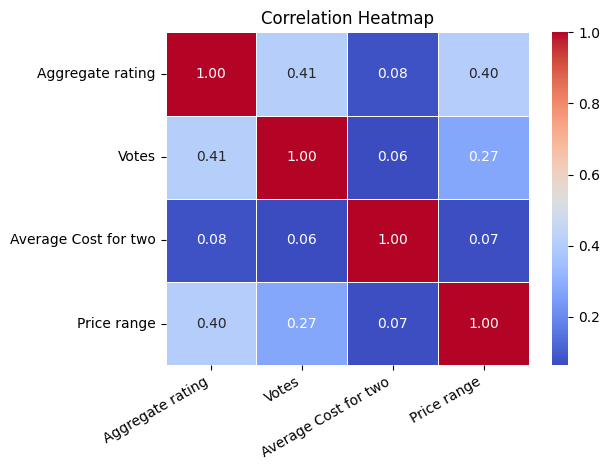

In [184]:
sns.heatmap(
    corr,
    annot=True,            # shows numbers inside boxes
    cmap="coolwarm",       # better color contrast
    fmt=".2f",             # 2 decimal places
    linewidths=0.5,
    xticklabels=corr.columns,
    yticklabels=corr.columns
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


1 Rating vs Votes (~0.4–0.5)  
 Moderate positive correlation  
 Restaurants with more votes tend to have slightly higher ratings

2 Votes vs Price Range (~0.3)  
 Weak positive correlation  
 Expensive restaurants get a bit more votes, but not strongly

3 Rating vs Price Range (~0.4)  
 Moderate correlation  
 Higher-priced restaurants often have slightly better ratings

4 Average Cost for Two ❗  
 Almost no correlation with anything  
 Exact cost doesn’t matter much, but price category does

## Univariate Analysis

### Ratings and Voting
